In [2]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)



Online learning environments generate vast amounts of interaction data, but a key question remains:
Can student engagement be used to predict academic success and dropout risk?

This analysis explores how online activity (measured through clicks) relates to student performance and retention.

In [3]:
import pandas as pd

df = pd.read_csv("/content/online_education_dataset.csv")

df.head()

,id_student,gender,region,highest_education,studied_credits,imd_band,total_clicks,avg_score,engagement_level,performance_level,risk_level,pass_flag,dropout_flag,final_result
0,11391,M,East Anglian Region,HE Qualification,240,90-100%,934.0,82.0,Medium,High,Low Risk,1,0,Pass
1,28400,F,Scotland,HE Qualification,60,20-30%,1435.0,66.4,Medium,Medium,Low Risk,1,0,Pass
2,30268,F,North Western Region,A Level or Equivalent,60,30-40%,281.0,NaN,Low,NaN,Very High Risk,0,1,Withdrawn
3,31604,F,South East Region,A Level or Equivalent,60,50-60%,2158.0,76.0,High,High,Low Risk,1,0,Pass
4,32885,F,West Midlands Region,Lower Than A Level,60,50-60%,1034.0,54.4,Medium,Medium,Low Risk,1,0,Pass


In [4]:
df["final_result"].value_counts()

,count
final_result,
Pass,12361
Withdrawn,10156
Fail,7052
Distinction,3024


The dataset includes students who passed, failed, achieved distinction, or withdrew.
A significant number of withdrawals suggests dropout is a major concern in online learning.

In [5]:
df.groupby("engagement_level")["pass_flag"].mean()

,pass_flag
engagement_level,
High,0.781354
Low,0.199194
Medium,0.571530


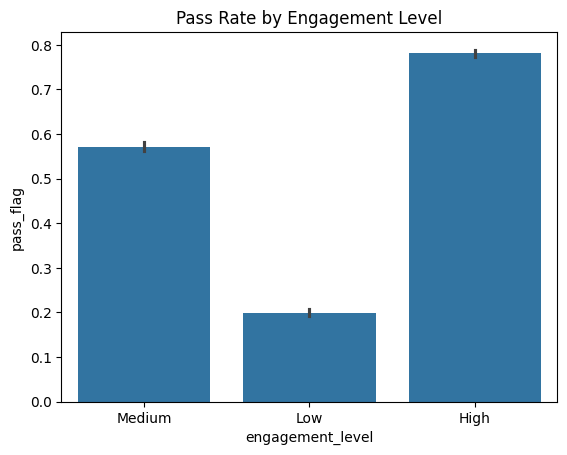

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="engagement_level", y="pass_flag", data=df)
plt.title("Pass Rate by Engagement Level")
sns.set_style("whitegrid")
plt.show()

Students with high engagement are nearly 4 times more likely to pass compared to low-engagement students.

There is a strong positive relationship between student engagement and academic success.
Students with high engagement levels are significantly more likely to pass, while low engagement students show a much higher risk of failure.

This suggests that engagement can be used as an early indicator of academic performance.

In [7]:
df[["total_clicks", "pass_flag"]].isnull().sum()

,0
total_clicks,2852
pass_flag,0


In [8]:
# Fix missing values properly (NO inplace)
df["total_clicks"] = df["total_clicks"].fillna(0)
df["pass_flag"] = df["pass_flag"].fillna(0)

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
X = df[["total_clicks"]]
y = df["pass_flag"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)

LogisticRegression(max_iter=1000)

In [10]:
print("Model coefficient:", model.coef_[0][0])

Model coefficient: 1.6158442072984183


The model coefficient is positive, indicating that higher engagement (clicks) increases the likelihood of passing.

This confirms that student activity is not just correlated with success, but can also be used as a predictive signal.


Engagement is a strong predictor of both academic success and dropout risk. Monitoring student activity can enable early interventions and improve learning outcomes.

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


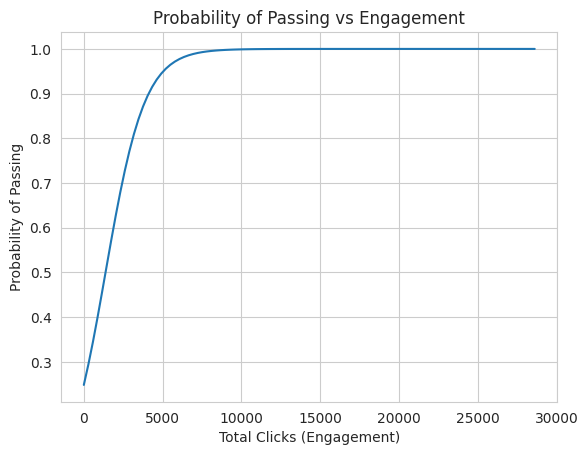

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Generate range of clicks
clicks_range = np.linspace(df["total_clicks"].min(), df["total_clicks"].max(), 100).reshape(-1,1)

# Scale it
clicks_scaled = scaler.transform(clicks_range)

# Predict probability
prob = model.predict_proba(clicks_scaled)[:,1]

# Plot
plt.plot(clicks_range, prob)
plt.xlabel("Total Clicks (Engagement)")
plt.ylabel("Probability of Passing")
plt.title("Probability of Passing vs Engagement")
sns.set_style("whitegrid")
plt.show()

The probability of passing increases steadily with engagement.
This visualization highlights how even incremental increases in student activity can significantly improve success outcomes.


<Axes: xlabel='engagement_level', ylabel='pass_flag'>

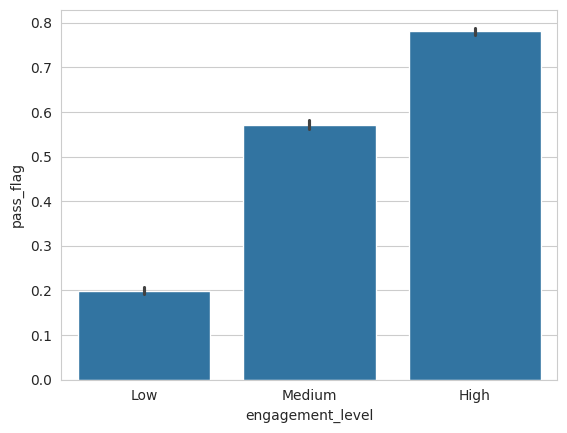

In [12]:
sns.barplot(
    x="engagement_level",
    y="pass_flag",
    data=df,
    order=["Low","Medium","High"]
)

Engagement is not just a descriptive metric—it is a powerful predictive signal.

Monitoring student activity can help identify at-risk students early and improve outcomes through timely interventions.